In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 10
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"
  from IPython.display import set_matplotlib_formats
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'RDpcUmVwb3NpdG9yaWVzXEFENjk4LWdlbmVyYXRpdmUtYWktZm9yLUJBXE0y'
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Program Files\\Python312\\Lib\\importlib\\_bootstrap.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\importlib\\_bootstrap_external.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\zipimport.py": 1744131414.0, "C:\\Program Files\\Python312\\Lib\\codecs.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\encodings\\aliases.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\encodings\\__init__.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\encodings\\utf_8.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\encodings\\cp1252.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\abc.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\io.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\stat.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\_collections_abc.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\genericpath.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\ntpath.py": 1744131412.0, "C:\\Program Files\\Python312\\Lib\\o

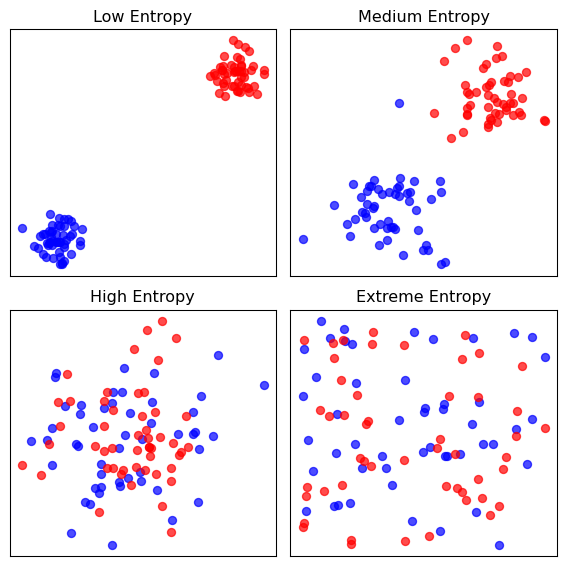

In [2]:
#| eval: true
#| echo: false
#| fig-cap: Different levels of entropy in 2D data
#| fig-alt: Scatter plots showing low, medium, high, and extreme entropy distributions.
#| fig-align: center
#| label: fig-entropy


import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

def make_cluster(center, n=50, spread=0.1):
    return np.random.randn(n, 2) * spread + np.array(center)

# Low entropy: two clean clusters
low_class0 = make_cluster([0, 0], spread=0.08)
low_class1 = make_cluster([1, 1], spread=0.08)

# Medium entropy: clusters closer, slight overlap
med_class0 = make_cluster([0.2, 0.2], spread=0.15)
med_class1 = make_cluster([0.8, 0.8], spread=0.15)

# High entropy: strong overlap
high_class0 = make_cluster([0.5, 0.5], spread=0.25)
high_class1 = make_cluster([0.55, 0.55], spread=0.25)

# Extreme entropy: fully mixed random points
extreme_class0 = np.random.rand(50, 2)
extreme_class1 = np.random.rand(50, 2)

fig, axes = plt.subplots(2, 2, figsize=(6, 6))

# Plot helper
def plot(ax, c0, c1, title):
    ax.scatter(c0[:,0], c0[:,1], color='blue', alpha=0.7, label='Class 0')
    ax.scatter(c1[:,0], c1[:,1], color='red', alpha=0.7, label='Class 1')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])

plot(axes[0,0], low_class0, low_class1, "Low Entropy")
plot(axes[0,1], med_class0, med_class1, "Medium Entropy")
plot(axes[1,0], high_class0, high_class1, "High Entropy")
plot(axes[1,1], extreme_class0, extreme_class1, "Extreme Entropy")

plt.tight_layout()
plt.show()

In [3]:
#| eval: true
#| echo: false

import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

penguins = sns.load_dataset("penguins").dropna()

penguins["label"] = (penguins["species"] == "Adelie").astype(int)

X = penguins[["bill_length_mm", "bill_depth_mm"]]
y = penguins["label"]

trainX, testX, trainy, testy = train_test_split(X, y, test_size=0.3, random_state=42)

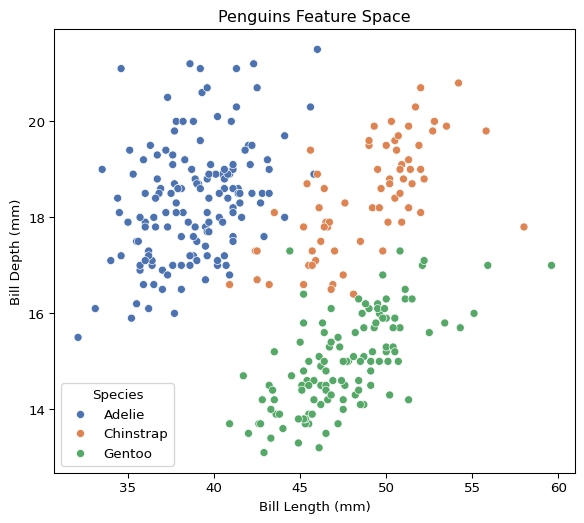

In [4]:
#| eval: true
#| echo: false
#| fig-align: center
#| fig-cap: "Penguins feature space: bill length vs. bill depth, colored by species."
#| fig-alt: "Scatter plot of penguin bill length vs. bill depth, with points colored by species (Adelie, Gentoo, Chinstrap)."
plt.figure(figsize=(7,6))
sns.scatterplot(
    data=penguins,
    x="bill_length_mm",
    y="bill_depth_mm",
    hue="species",
    palette="deep"
)
plt.title("Penguins Feature Space")
plt.xlabel("Bill Length (mm)")
plt.ylabel("Bill Depth (mm)")
plt.legend(title="Species")
plt.show()

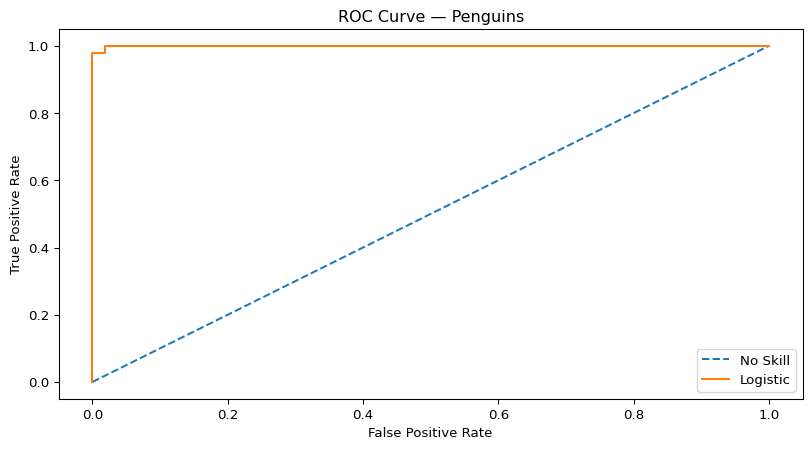

ROC AUC: 0.9995993589743589


In [5]:
#| eval: true
#| echo: false 
#| fig-align: center
#| fig-cap: "ROC curve for logistic regression on penguin data."
model = LogisticRegression()
model.fit(trainX, trainy)

probs = model.predict_proba(testX)[:, 1]
fpr, tpr, _ = roc_curve(testy, probs)


plt.plot([0,1], [0,1], '--', label="No Skill")
plt.plot(fpr, tpr, label="Logistic")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Penguins")
plt.legend()
plt.show()

print("ROC AUC:", roc_auc_score(testy, probs))

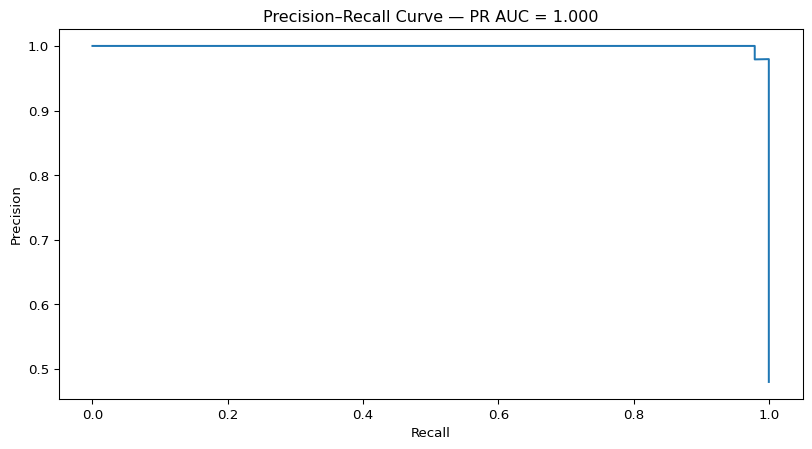

In [6]:
#| eval: true
#| echo: false 
#| fig-align: center
precision, recall, _ = precision_recall_curve(testy, probs)
pr_auc = auc(recall, precision)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title(f"Precision–Recall Curve — PR AUC = {pr_auc:.3f}")
plt.show()

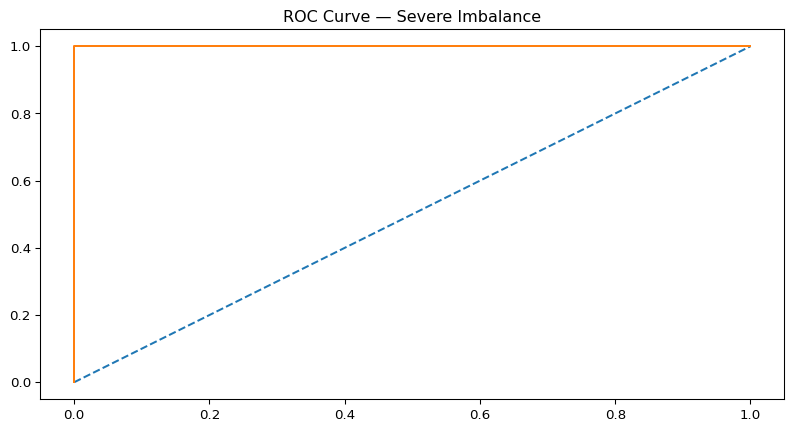

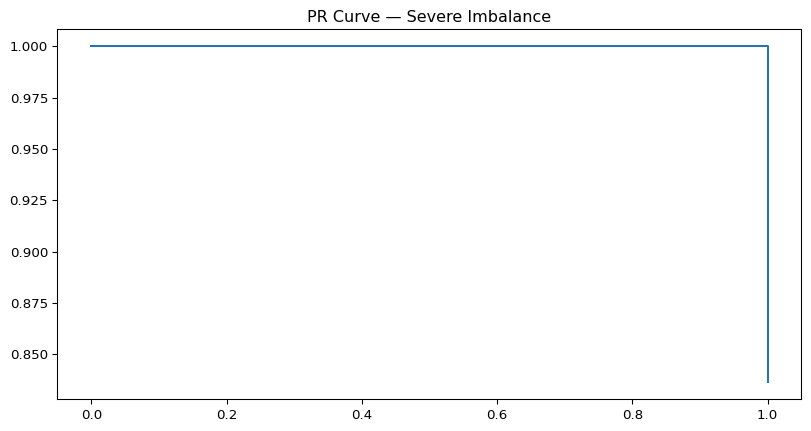

In [7]:
#| eval: true
#| echo: false 
#| fig-align: center
minority = penguins[penguins["label"] == 1]
majority = penguins[penguins["label"] == 0].sample(frac=0.2, random_state=42)

imbalanced = pd.concat([minority, majority])
X_imb = imbalanced[["bill_length_mm", "bill_depth_mm"]]
y_imb = imbalanced["label"]

trainX, testX, trainy, testy = train_test_split(X_imb, y_imb, test_size=0.3, random_state=42)

model.fit(trainX, trainy)
probs = model.predict_proba(testX)[:, 1]

# ROC
fpr, tpr, _ = roc_curve(testy, probs)
plt.plot([0,1], [0,1], '--')
plt.plot(fpr, tpr)
plt.title("ROC Curve — Severe Imbalance")
plt.show()

# PR
precision, recall, _ = precision_recall_curve(testy, probs)
plt.plot(recall, precision)
plt.title("PR Curve — Severe Imbalance")
plt.show()